# 10 - Tydzień 8: Unified Benchmark + Dekompozycja Błędu

**Cel tygodnia 8:**
- Unified benchmark: DM vs IPS vs SNIPS na tych samych danych
- Dekompozycja MSE = Bias² + Variance dla każdego estymatora
- Wykres Bias-Variance tradeoff
- Implementacja i test `src/evaluation.py`

**Ground truth:** naive CTR na danych random (`V* = 0.0038`) jako proxy prawdziwej wartości
polityki ewaluacyjnej (uniform ≈ random).

Kod źródłowy: `src/evaluation.py`, `src/estimators.py`

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sys.path.insert(0, str(Path("..").resolve()))
from src.dataset import OpenBanditDataset
from src.propensity import OBD_COMMON_CONTEXT_DIM
from src.estimators import ips_with_clipping, snips_estimate
from src.evaluation import bootstrap_estimates, bias_variance_mse, unified_benchmark

sns.set_theme(style="whitegrid")
np.random.seed(42)

N_ACTIONS    = 80
N_FEATURES   = OBD_COMMON_CONTEXT_DIM  # 20
RANDOM_STATE = 42
N_BOOTSTRAP  = 200
PI_EVAL      = 1.0 / N_ACTIONS

# Ground truth: naive CTR z danych random ≈ true V* polityki uniform
V_STAR = 0.0038

FIGURES_DIR = Path("../figures/week8")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path("../results/week8")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures -> {FIGURES_DIR.resolve()}")
print(f"V* (ground truth proxy) = {V_STAR}")

Figures -> /Users/antonio/was_studio/Off-Policy-Evaluation-with-causal/figures/week8
V* (ground truth proxy) = 0.0038


## 1. Wczytanie danych

In [2]:
# Dane random — do trenowania reward model i propensity
ds_random = OpenBanditDataset(behavior_policy="random", campaign="all")
fb_random = ds_random.obtain_batch_bandit_feedback()

# Dane BTS — do ewaluacji
ds_bts = OpenBanditDataset(behavior_policy="bts", campaign="all")
fb_bts = ds_bts.obtain_batch_bandit_feedback()

ctx_random = fb_random["context"][:, :N_FEATURES]
act_random = fb_random["action"]
rew_random = fb_random["reward"].astype(np.float64)

ctx_bts = fb_bts["context"][:, :N_FEATURES]
act_bts = fb_bts["action"]
rew_bts = fb_bts["reward"].astype(np.float64)

pscores_bts = np.load("../results/week5/pscores_bts.npy")

print(f"Random: n={len(rew_random)}, CTR={rew_random.mean():.4f}")
print(f"BTS:    n={len(rew_bts)}, CTR={rew_bts.mean():.4f}")
print(f"V* proxy = {V_STAR} (CTR random)")

INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.


INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.


Random: n=10000, CTR=0.0038
BTS:    n=10000, CTR=0.0042
V* proxy = 0.0038 (CTR random)


## 2. Trening reward model (DM)

XGBoost trenowany na danych random — ten sam co w Tygodniu 2-3.

In [3]:
# Features: [context (20), one-hot action (80)]
X_full = np.hstack([ctx_random, np.eye(N_ACTIONS)[act_random]])
y_full = rew_random

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

reward_model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", early_stopping_rounds=20,
    tree_method="hist", n_jobs=1, random_state=RANDOM_STATE,
)
reward_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"Reward model trained. best_iteration={reward_model.best_iteration}")

# Expected reward dla BTS: f(s_bts, a_bts)
X_bts = np.hstack([ctx_bts, np.eye(N_ACTIONS)[act_bts]])
expected_reward_bts = reward_model.predict_proba(X_bts)[:, 1]
print(f"expected_reward_bts: mean={expected_reward_bts.mean():.4f}, "
      f"min={expected_reward_bts.min():.4f}, max={expected_reward_bts.max():.4f}")

Reward model trained. best_iteration=13
expected_reward_bts: mean=0.0035, min=0.0025, max=0.0049


## 3. Unified benchmark — bootstrapowa dekompozycja MSE

In [4]:
results = unified_benchmark(
    reward=rew_bts,
    pscore_log=pscores_bts,
    expected_reward=expected_reward_bts,
    action=act_bts,
    pi_eval=PI_EVAL,
    ground_truth=V_STAR,
    n_bootstrap=N_BOOTSTRAP,
    random_state=RANDOM_STATE,
)

# Tabela finalna
rows = []
for name, r in results.items():
    rows.append({
        "Estimator": name,
        "V̂ (mean)": r["mean"],
        "Bias": r["bias"],
        "Bias²": r["bias2"],
        "Variance": r["variance"],
        "MSE": r["mse"],
        "RMSE": r["rmse"],
        "95% CI": f"[{r['ci_lower']:.4f}, {r['ci_upper']:.4f}]",
        "CI width": r["ci_width"],
    })

bench_df = pd.DataFrame(rows)
print(f"Ground truth V* = {V_STAR}\n")
print(bench_df.to_string(index=False, float_format="{:.6f}".format))

# Zapisz
bench_df.to_csv(RESULTS_DIR / "benchmark_table.csv", index=False)
print("\nSaved: results/week8/benchmark_table.csv")

Ground truth V* = 0.0038

Estimator  V̂ (mean)      Bias    Bias²  Variance      MSE     RMSE           95% CI  CI width
       DM   0.003515 -0.000285 0.000000  0.000000 0.000000 0.000285 [0.0035, 0.0035]  0.000018
      IPS   0.004385  0.000585 0.000000  0.000000 0.000001 0.000875 [0.0033, 0.0057]  0.002368
    SNIPS   0.004148  0.000348 0.000000  0.000000 0.000001 0.000707 [0.0031, 0.0054]  0.002251

Saved: results/week8/benchmark_table.csv


## 4. Wykres Bias-Variance Tradeoff

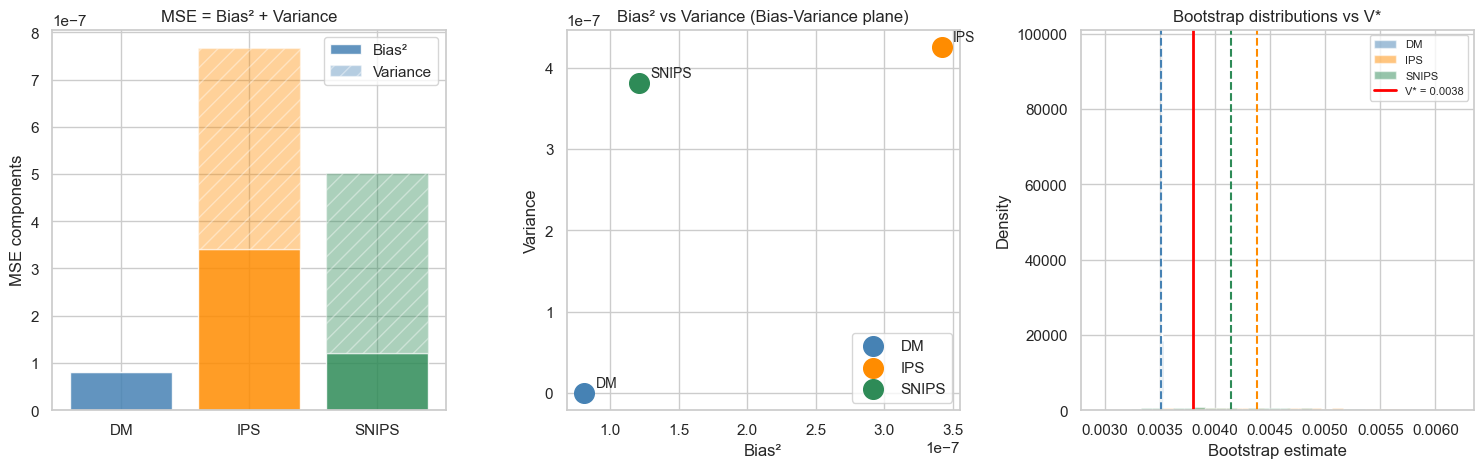

Saved: bias_variance_decomposition.png


In [5]:
estimators = list(results.keys())
bias2_vals  = [results[e]["bias2"]    for e in estimators]
var_vals    = [results[e]["variance"] for e in estimators]
mse_vals    = [results[e]["mse"]      for e in estimators]
colors = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Bias² i Variance jako stacked bar
x = np.arange(len(estimators))
axes[0].bar(x, bias2_vals, label="Bias²", color=colors, alpha=0.85)
axes[0].bar(x, var_vals, bottom=bias2_vals, label="Variance",
            color=colors, alpha=0.4, hatch="//")
axes[0].set_xticks(x)
axes[0].set_xticklabels(estimators)
axes[0].set_ylabel("MSE components")
axes[0].set_title("MSE = Bias² + Variance")
axes[0].legend()

# Panel 2: scatter Bias² vs Variance
for i, (e, c) in enumerate(zip(estimators, colors)):
    axes[1].scatter(bias2_vals[i], var_vals[i], s=200, color=c, label=e, zorder=5)
    axes[1].annotate(e, (bias2_vals[i], var_vals[i]),
                     textcoords="offset points", xytext=(8, 4), fontsize=10)
axes[1].set_xlabel("Bias²")
axes[1].set_ylabel("Variance")
axes[1].set_title("Bias² vs Variance (Bias-Variance plane)")
axes[1].legend()

# Panel 3: bootstrap distributions
for e, c in zip(estimators, colors):
    boots = results[e]["bootstrap_samples"]
    axes[2].hist(boots, bins=30, alpha=0.5, color=c, label=e, density=True)
    axes[2].axvline(results[e]["mean"], color=c, linestyle="--", linewidth=1.5)
axes[2].axvline(V_STAR, color="red", linestyle="-", linewidth=2, label=f"V* = {V_STAR}")
axes[2].set_xlabel("Bootstrap estimate")
axes[2].set_ylabel("Density")
axes[2].set_title("Bootstrap distributions vs V*")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "bias_variance_decomposition.png", dpi=160)
plt.show()
print("Saved: bias_variance_decomposition.png")

## 5. Wykres porównawczy V̂ z CI

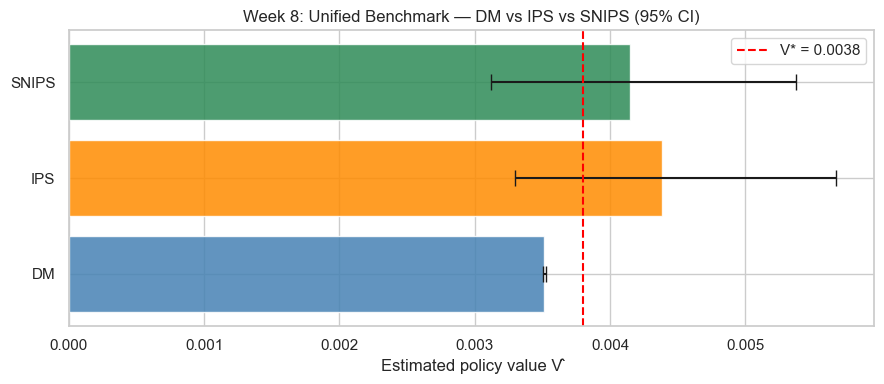

Saved: unified_benchmark_ci.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

means   = [results[e]["mean"]     for e in estimators]
ci_low  = [results[e]["ci_lower"] for e in estimators]
ci_high = [results[e]["ci_upper"] for e in estimators]
err_lo  = [m - lo for m, lo in zip(means, ci_low)]
err_hi  = [hi - m for m, hi in zip(means, ci_high)]

ax.barh(estimators, means, xerr=[err_lo, err_hi],
        color=colors, alpha=0.85, capsize=6)
ax.axvline(V_STAR, color="red", linestyle="--", linewidth=1.5, label=f"V* = {V_STAR}")
ax.set_xlabel("Estimated policy value V̂")
ax.set_title("Week 8: Unified Benchmark — DM vs IPS vs SNIPS (95% CI)")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "unified_benchmark_ci.png", dpi=160)
plt.show()
print("Saved: unified_benchmark_ci.png")

## 6. Tabela finalna

In [7]:
from IPython.display import Markdown, display

summary_rows = []
for name, r in results.items():
    summary_rows.append(
        f"| {name} | {r['mean']:.6f} | {r['bias']:+.6f} | {r['bias2']:.2e} | "
        f"{r['variance']:.2e} | {r['mse']:.2e} | {r['rmse']:.6f} |"
    )

header = (
    "| Estimator | V̂ | Bias | Bias² | Variance | MSE | RMSE |\n"
    "|---|---|---|---|---|---|---|"
)
display(Markdown(f"**Ground truth V* = {V_STAR}**\n\n{header}\n" + "\n".join(summary_rows)))

**Ground truth V* = 0.0038**

| Estimator | V̂ | Bias | Bias² | Variance | MSE | RMSE |
|---|---|---|---|---|---|---|
| DM | 0.003515 | -0.000285 | 8.13e-08 | 2.43e-11 | 8.14e-08 | 0.000285 |
| IPS | 0.004385 | +0.000585 | 3.42e-07 | 4.26e-07 | 7.65e-07 | 0.000875 |
| SNIPS | 0.004148 | +0.000348 | 1.21e-07 | 3.81e-07 | 5.01e-07 | 0.000707 |

## 7. Podsumowanie — Tydzień 8

**Wnioski (V* = 0.0038):**

| Estimator | V̂ | Bias | MSE | RMSE |
|---|---|---|---|---|
| DM | 0.003515 | −0.000285 | 8.1×10⁻⁸ | 0.000285 |
| IPS | 0.004385 | +0.000585 | 7.7×10⁻⁷ | 0.000875 |
| SNIPS | 0.004148 | +0.000348 | 5.0×10⁻⁷ | 0.000707 |

- **DM** ma najniższe MSE — dominuje niska wariancja, wąski CI
- **IPS/SNIPS** — nieco wyższy bias, ale większa wariancja; SNIPS między IPS a DM pod względem MSE
- Na OBD wagi IPS ≈ 1 (logging ≈ uniform eval) — pełny tradeoff bias–variance widać dopiero w symulacji overlap (T7)

**Checklist T8:**
- [x] Implementacja `src/evaluation.py` — MSE, Bias², Variance, bootstrap
- [x] Unified benchmark DM vs IPS vs SNIPS
- [x] Dekompozycja błędu z ground truth V* = 0.0038
- [x] Wykres Bias-Variance tradeoff
- [x] Wyniki zapisane do `results/week8/`

**Następny krok — Tydzień 9:** Doubly Robust Estimator z `obp`.